In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

project_root = Path(r"C:\AMDARI PROJECTS\DISASTER RECOVERY COST PREDICTION")
processed_path = project_root / "data" / "processed" / "processed_disasters.csv"

df = pd.read_csv(processed_path)

print(df.shape)
df.head()

(5174, 21)


,disasterNumber,state,incidentType,declarationDate,incidentBeginDate,incidentEndDate,declarationType,region,declaration_year,declaration_month,...,season,total_obligated_pa,federal_share_pa,project_count,avg_project_amount,totalObligatedAmountPa,state_5yr_disaster_count,high_cost_incident,target_total_obligated,target_log_total_obligated
0,13,AK,Other,1953-10-30 00:00:00+00:00,1953-10-30 00:00:00+00:00,1953-10-30 00:00:00+00:00,DR,10,1953,10,...,Autumn,0.0,NaN,NaN,NaN,NaN,0,False,0.0,0.0
1,31,AK,Other,1954-11-10 00:00:00+00:00,1954-11-10 00:00:00+00:00,1954-11-10 00:00:00+00:00,DR,10,1954,11,...,Autumn,0.0,NaN,NaN,NaN,NaN,1,False,0.0,0.0
2,46,AK,Other,1955-12-22 00:00:00+00:00,1955-12-22 00:00:00+00:00,1955-12-22 00:00:00+00:00,DR,10,1955,12,...,Winter,0.0,NaN,NaN,NaN,NaN,2,False,0.0,0.0
3,168,AK,Earthquake,1964-03-28 00:00:00+00:00,1964-03-28 00:00:00+00:00,1964-03-28 00:00:00+00:00,DR,10,1964,3,...,Spring,0.0,NaN,NaN,NaN,NaN,0,False,0.0,0.0
4,230,AK,Flood,1967-08-17 00:00:00+00:00,1967-08-17 00:00:00+00:00,1967-08-17 00:00:00+00:00,DR,10,1967,8,...,Summer,0.0,NaN,NaN,NaN,NaN,1,True,0.0,0.0


In [2]:
df.info()

nulls = (
    df.isna().mean()
    .sort_values(ascending=False)
    .rename("null_fraction")
)

nulls[nulls > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5174 entries, 0 to 5173
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   disasterNumber              5174 non-null   int64  
 1   state                       5174 non-null   object 
 2   incidentType                5174 non-null   object 
 3   declarationDate             5174 non-null   object 
 4   incidentBeginDate           5174 non-null   object 
 5   incidentEndDate             4869 non-null   object 
 6   declarationType             5174 non-null   object 
 7   region                      5174 non-null   int64  
 8   declaration_year            5174 non-null   int64  
 9   declaration_month           5174 non-null   int64  
 10  incident_duration_days      5174 non-null   float64
 11  season                      5174 non-null   object 
 12  total_obligated_pa          5174 non-null   float64
 13  federal_share_pa            1766 

avg_project_amount        0.658678
project_count             0.658678
federal_share_pa          0.658678
totalObligatedAmountPa    0.423077
incidentEndDate           0.058949
Name: null_fraction, dtype: float64

In [3]:
numeric_cols = [
    "incident_duration_days",
    "project_count",
    "avg_project_amount",
    "federal_share_pa",
    "total_obligated_pa",
    "target_total_obligated",
    "target_log_total_obligated",
    "state_5yr_disaster_count",
]

df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
incident_duration_days,5174.0,5.141593e+01,2.249087e+02,0.00,0.000000e+00,4.000000e+00,1.400000e+01,5.117000e+03
project_count,1766.0,4.593069e+02,9.716655e+02,1.00,5.600000e+01,1.630000e+02,4.690000e+02,1.383600e+04
avg_project_amount,1766.0,2.674485e+05,8.408963e+05,4259.15,3.379523e+04,7.424587e+04,1.833734e+05,1.992886e+07
federal_share_pa,1766.0,1.574378e+08,1.331065e+09,3194.36,3.283312e+06,8.924920e+06,3.016299e+07,3.632722e+10
total_obligated_pa,5174.0,5.383640e+07,7.816023e+08,0.00,0.000000e+00,0.000000e+00,3.625681e+06,3.632722e+10
target_total_obligated,5174.0,5.383640e+07,7.816023e+08,0.00,0.000000e+00,0.000000e+00,3.625681e+06,3.632722e+10
target_log_total_obligated,5174.0,5.509405e+00,7.740769e+00,0.00,0.000000e+00,0.000000e+00,1.510355e+01,2.431583e+01
state_5yr_disaster_count,5174.0,1.572980e+01,1.981294e+01,0.00,4.000000e+00,9.000000e+00,1.600000e+01,1.220000e+02


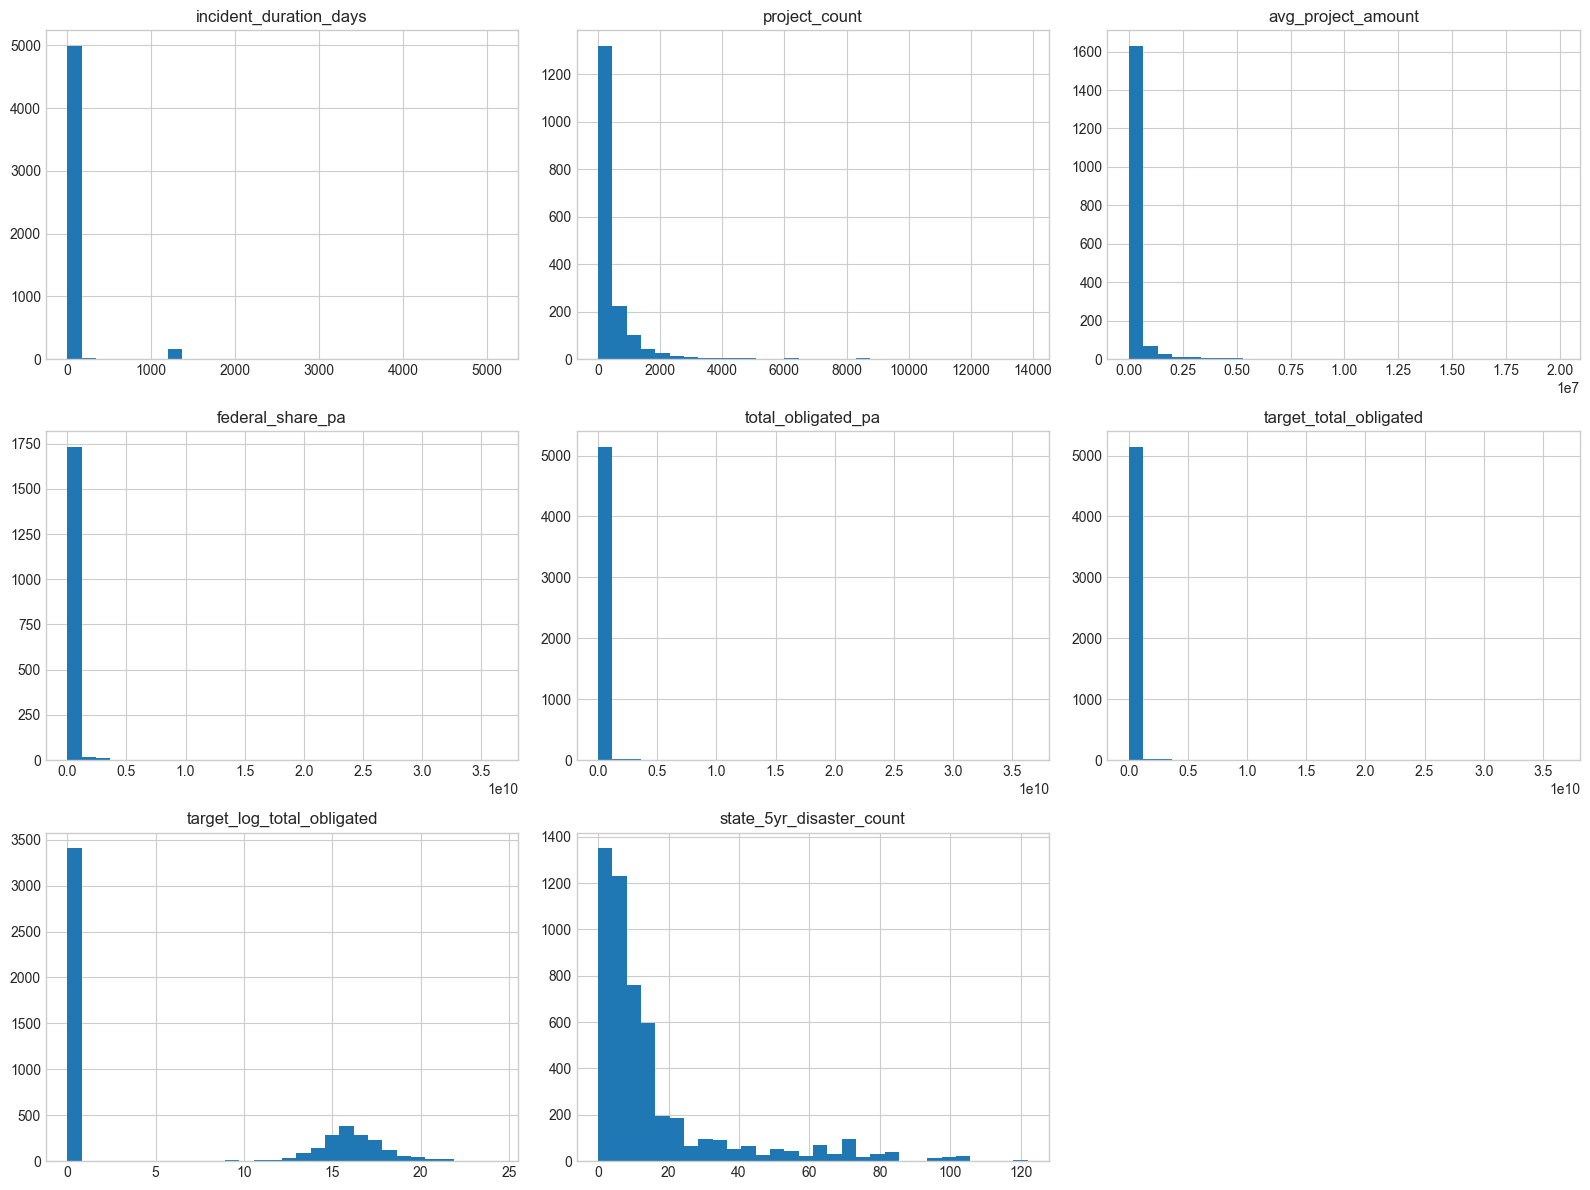

In [4]:
df[numeric_cols].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

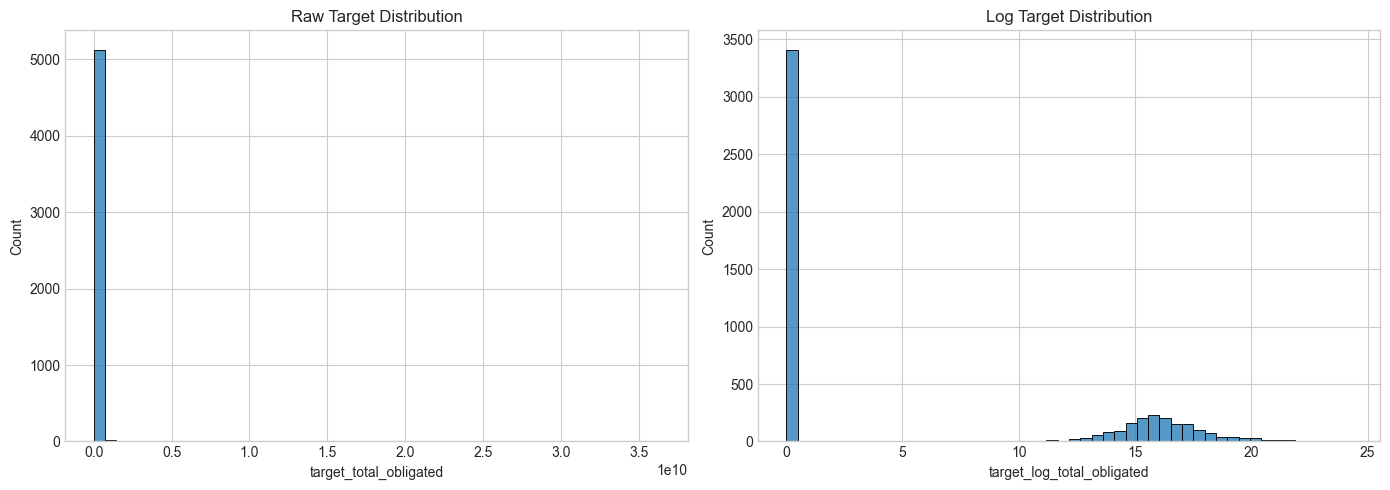

In [5]:
# Target distribution: raw vs log
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["target_total_obligated"], bins=50, ax=axes[0])
axes[0].set_title("Raw Target Distribution")
axes[0].set_xlabel("target_total_obligated")

sns.histplot(df["target_log_total_obligated"], bins=50, ax=axes[1])
axes[1].set_title("Log Target Distribution")
axes[1].set_xlabel("target_log_total_obligated")

plt.tight_layout()
plt.show()

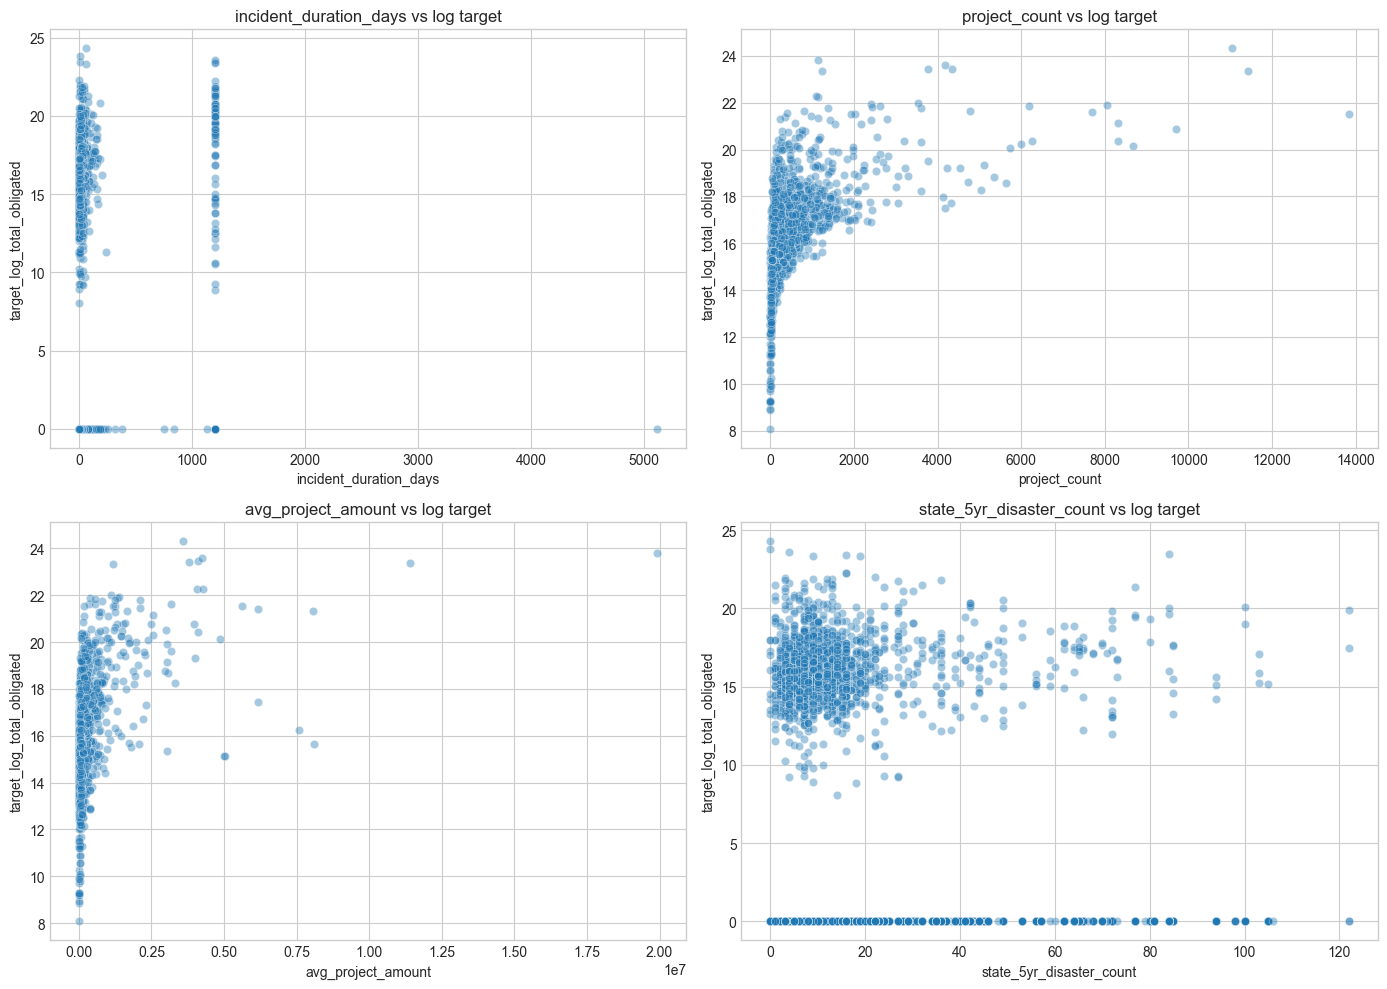

In [6]:
# Feature vs target scatter plots

scatter_features = [
    "incident_duration_days",
    "project_count",
    "avg_project_amount",
    "state_5yr_disaster_count",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, scatter_features):
    sns.scatterplot(
        data=df,
        x=col,
        y="target_log_total_obligated",
        alpha=0.4,
        ax=ax
    )
    ax.set_title(f"{col} vs log target")

plt.tight_layout()
plt.show()

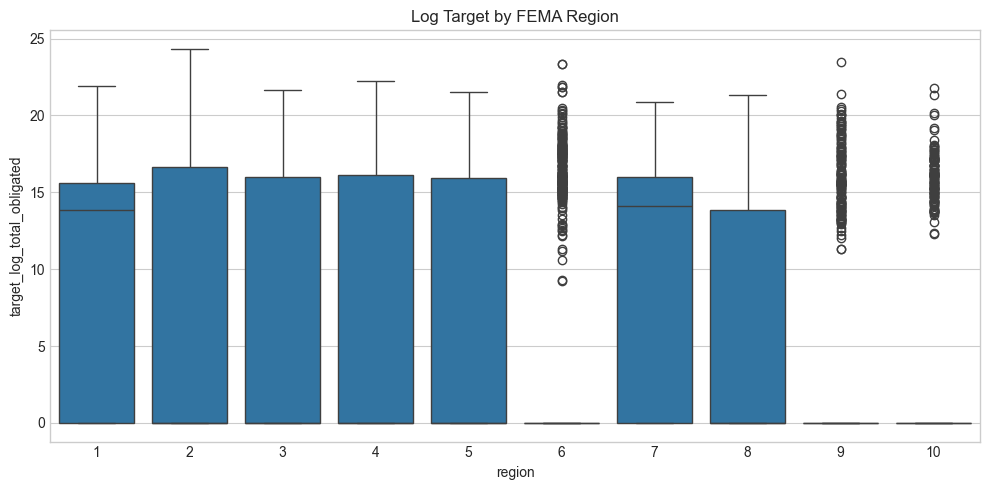

In [7]:
# Boxplots by categorical features

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="region", y="target_log_total_obligated")
plt.title("Log Target by FEMA Region")
plt.tight_layout()
plt.show()

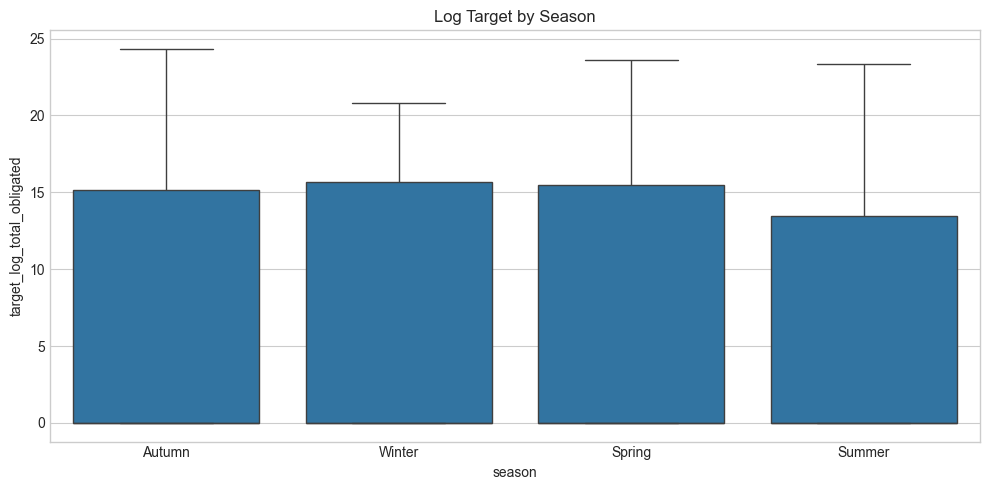

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="season", y="target_log_total_obligated")
plt.title("Log Target by Season")
plt.tight_layout()
plt.show()

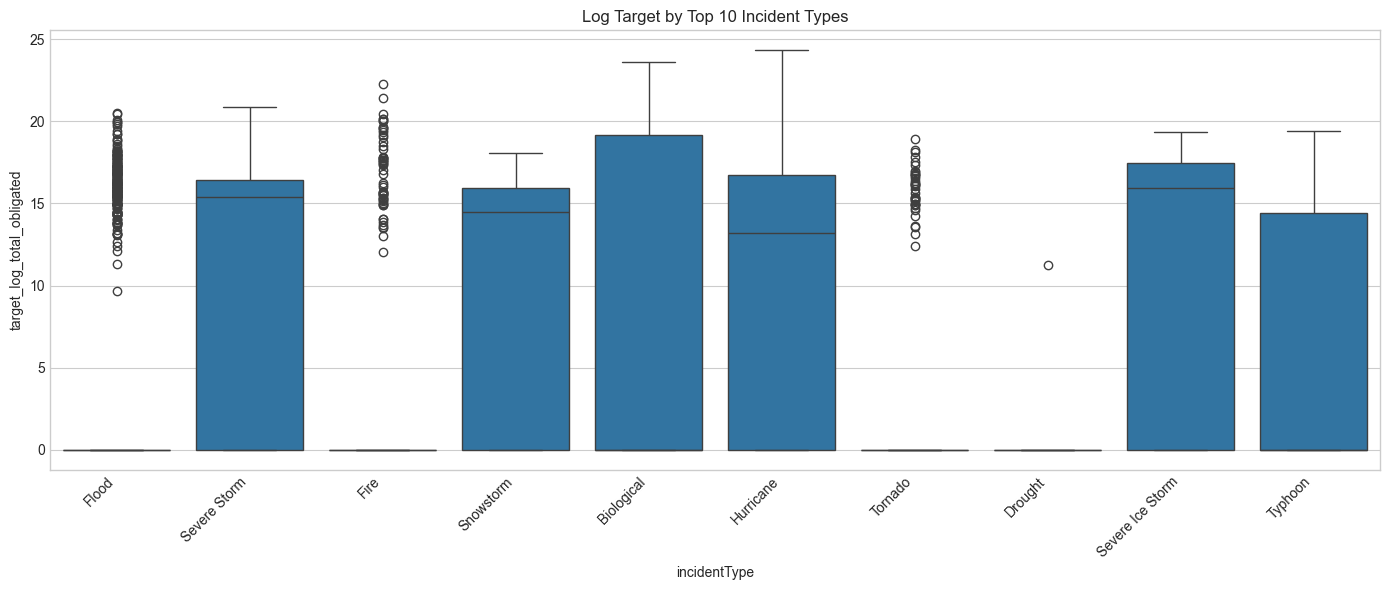

In [9]:
top_incidents = df["incidentType"].value_counts().head(10).index
plot_df = df[df["incidentType"].isin(top_incidents)]

plt.figure(figsize=(14, 6))
sns.boxplot(data=plot_df, x="incidentType", y="target_log_total_obligated")
plt.xticks(rotation=45, ha="right")
plt.title("Log Target by Top 10 Incident Types")
plt.tight_layout()
plt.show()

In [10]:
# Validating high_cost_incident

df.groupby("high_cost_incident")["target_total_obligated"].describe()

,count,mean,std,min,25%,50%,75%,max
high_cost_incident,,,,,,,,
False,2493.0,4.646668e+07,5.883383e+08,0.0,0.0,0.00,0.00,1.755774e+10
True,2681.0,6.068934e+07,9.258618e+08,0.0,0.0,19645.54,9038145.22,3.632722e+10


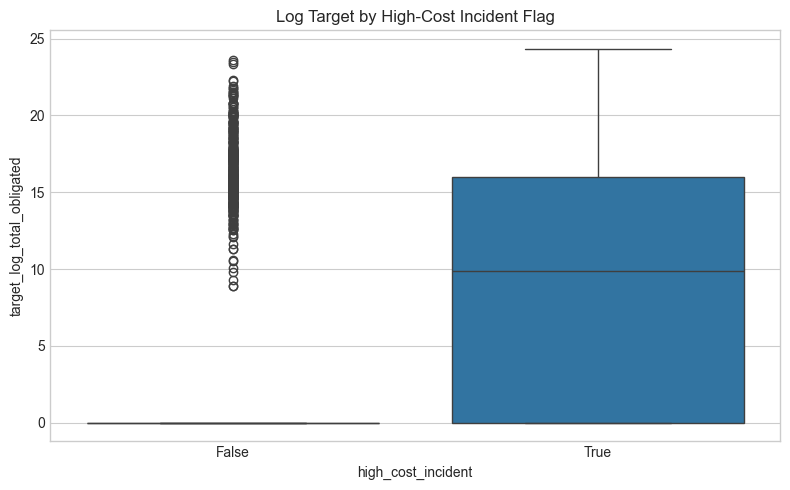

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="high_cost_incident", y="target_log_total_obligated")
plt.title("Log Target by High-Cost Incident Flag")
plt.tight_layout()
plt.show()

In [12]:
df.groupby("high_cost_incident")["incidentType"].value_counts().head(20)

high_cost_incident  incidentType       
False               Fire                   1732
                    Snowstorm               171
                    Biological              167
                    Severe Ice Storm         75
                    Typhoon                  58
                    Drought                  46
                    Tropical Storm           37
                    Earthquake               36
                    Other                    35
                    Winter Storm             32
                    Coastal Storm            31
                    Freezing                 18
                    Mud/Landslide            13
                    Toxic Substances          8
                    Dam/Levee Break           6
                    Fishing Losses            6
                    Volcanic Eruption         6
                    Straight-Line Winds       5
                    Human Cause               4
                    Tsunami                   3


In [13]:
# Class balance of categorical features

categorical_cols = ["incidentType", "season", "region", "high_cost_incident", "declarationType"]

for col in categorical_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))


=== incidentType ===
incidentType
Fire                   1732
Severe Storm           1128
Flood                   918
Hurricane               453
Tornado                 182
Snowstorm               171
Biological              167
Severe Ice Storm         75
Typhoon                  58
Drought                  46
Tropical Storm           37
Earthquake               36
Other                    35
Winter Storm             32
Coastal Storm            31
Freezing                 18
Mud/Landslide            13
Toxic Substances          8
Dam/Levee Break           6
Fishing Losses            6
Volcanic Eruption         6
Straight-Line Winds       5
Human Cause               4
Tsunami                   3
Terrorist                 2
Tropical Depression       1
Chemical                  1
Name: count, dtype: int64

=== season ===
season
Summer    1736
Spring    1472
Autumn    1209
Winter     757
Name: count, dtype: int64

=== region ===
region
6     966
4     794
9     788
10    531
8     490
5

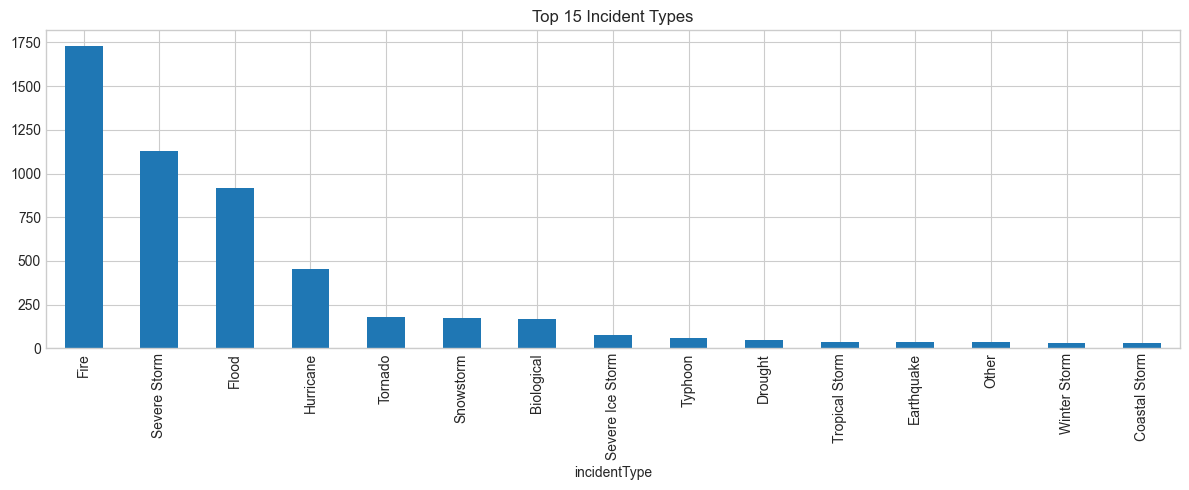

In [14]:
plt.figure(figsize=(12, 5))
df["incidentType"].value_counts().head(15).plot(kind="bar")
plt.title("Top 15 Incident Types")
plt.tight_layout()
plt.show()

In [15]:
# Remaining Outliers

q1 = df["target_log_total_obligated"].quantile(0.25)
q3 = df["target_log_total_obligated"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[
    (df["target_log_total_obligated"] < lower) |
    (df["target_log_total_obligated"] > upper)
]

print("Outlier count:", outliers.shape[0])
outliers[[
    "disasterNumber",
    "state",
    "incidentType",
    "target_total_obligated",
    "target_log_total_obligated"
]].head(20)

Outlier count: 0


,disasterNumber,state,incidentType,target_total_obligated,target_log_total_obligated
